# Quickstart: Single-Site Monthly Generation

This tutorial demonstrates the core SynHydro workflow: load observed data,
fit a generator, generate synthetic realizations, and plot the results.

> **Note:** Run this notebook from the `examples/` directory. Figures are saved to `figures/01_quickstart/` and data outputs to `outputs/01_quickstart/` (both are gitignored).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "01_quickstart"
OUT_DIR = Path("outputs") / "01_quickstart"
FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load example data

In [2]:
import synhydro

Q_daily = synhydro.load_example_data()       # multi-site daily DataFrame
Q_monthly = Q_daily.resample("MS").sum()     # aggregate to monthly
site = Q_monthly.columns[0]                  # pick one site
Q_single = Q_monthly[[site]]                 # keep as DataFrame

## Fit and generate

Every generator follows two steps: **fit**, **generate**.
`ThomasFieringGenerator` fits a seasonal AR(1) model to single-site monthly data.

In [3]:
gen = synhydro.ThomasFieringGenerator()
gen.fit(Q_single)
ensemble = gen.generate(n_realizations=50, n_years=30, seed=42)

The returned `Ensemble` contains 50 synthetic 30-year monthly timeseries.

In [4]:
Q_syn_0 = ensemble.data_by_realization[0]
print(Q_syn_0.shape)  # (360, 1) -- 30 years x 12 months

(360, 1)


> **Note (Seed reproducibility):** Passing the same `seed` value always produces identical results.

## Visualize

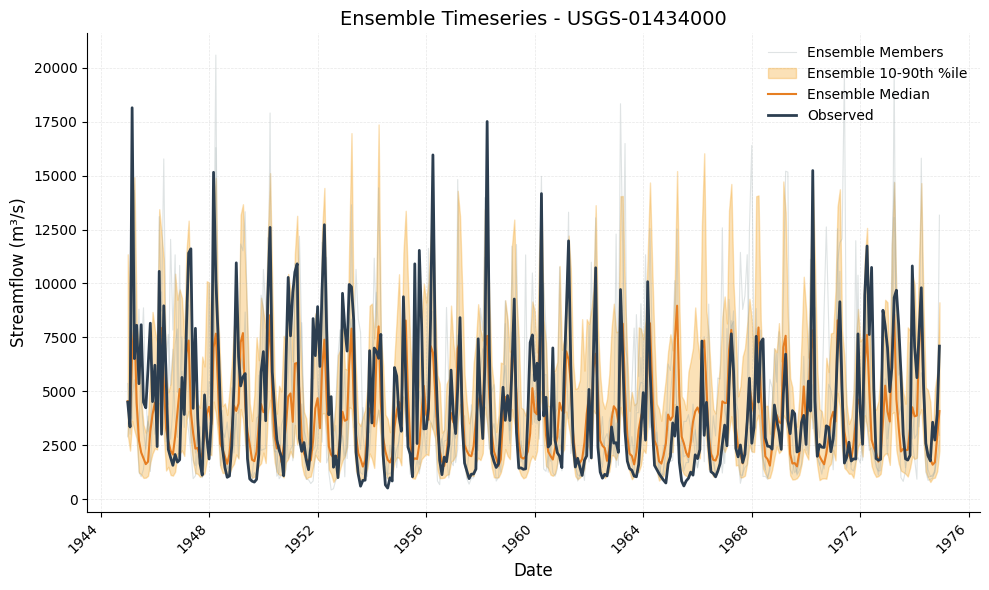

In [5]:
from synhydro.plotting import plot_timeseries, plot_flow_duration_curve

fig, ax = plot_timeseries(
    ensemble,
    observed=Q_monthly[site],
    show_members=3,
)
fig.savefig(FIG_DIR / "timeseries.png", dpi=150, bbox_inches="tight")

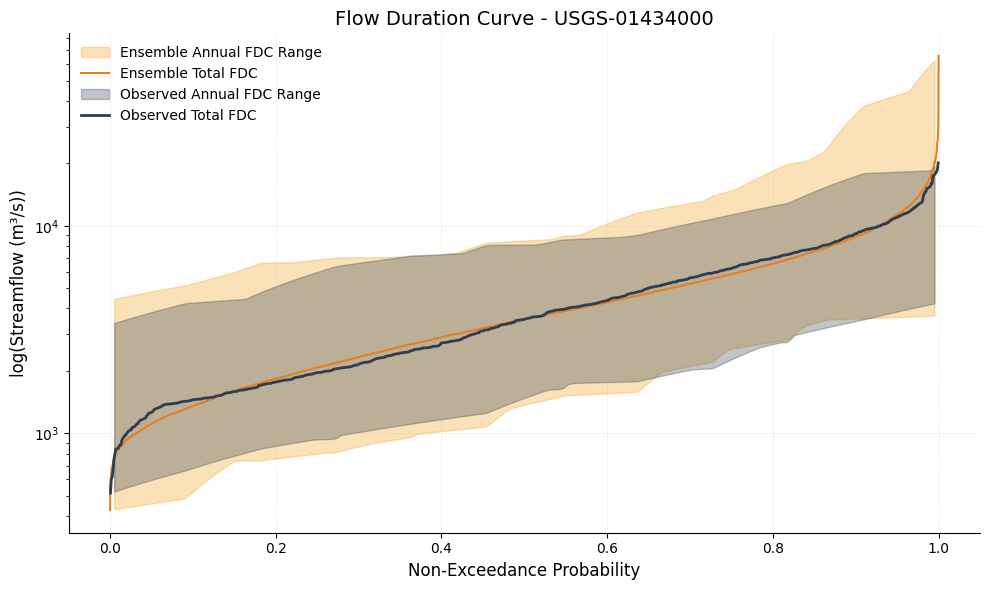

In [6]:
fig, ax = plot_flow_duration_curve(
    ensemble,
    observed=Q_monthly[site],
)
fig.savefig(FIG_DIR / "fdc.png", dpi=150, bbox_inches="tight")

## Next steps

- **Multi-site generation** - [Tutorial 02](../02_multisite/)
- **Monthly-to-daily disaggregation** - [Tutorial 03](../03_disaggregator/)
- **Algorithm details** - [Thomas-Fiering AR(1)](../../algorithms/thomas_fiering/)

---

**Next:** [Multi-Site Monthly (Kirsch)](../02_multisite/)